In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
df = pd.read_csv("apartments.csv")
X = df.drop(columns="type")
y = df["type"]

In [3]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression model
model = LogisticRegressionCV(
    solver='lbfgs',             # Efficient for multiclass
    multi_class='multinomial', # Softmax-based multiclass prediction - deprecated
    cv=5,
    max_iter=500
)
model.fit(X_train_scaled, y_train)

# Predict on test set and print report
y_pred = model.predict(X_test_scaled)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

   apartment       1.00      0.07      0.13        14
      garden       0.17      0.25      0.20         8
   penthouse       0.25      0.50      0.33        12
      studio       0.12      0.09      0.11        11

    accuracy                           0.22        45
   macro avg       0.39      0.23      0.19        45
weighted avg       0.44      0.22      0.19        45



/home/michael/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1908: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


#### Accuracy: 22% — poor.

In [4]:
# Print learned coefficients
print("\nModel Coefficients (per class):")
coef_df = pd.DataFrame(model.coef_, columns=X.columns, index=model.classes_)
print(coef_df)


Model Coefficients (per class):
               area     rooms       age  distance
apartment  0.044284  0.010453 -0.078812 -0.191507
garden     0.022876 -0.059263 -0.047248  0.147000
penthouse -0.017556  0.113631  0.130172 -0.051329
studio    -0.049604 -0.064820 -0.004112  0.095837


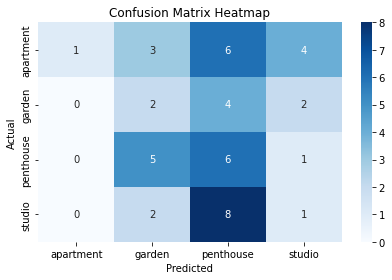

In [5]:
# Plot confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.tight_layout()
plt.show()

#### Model has poor performance, in diagonal dark blue is not dominant

In [6]:
# Predict a specific custom case
print("For an example case: 90 m^2 area, 4 rooms, 10 years age, distance 4 Km")
sample = np.array([[90, 4, 10, 4]])  # Example input
sample_scaled = scaler.transform(sample)
predicted_class = model.predict(sample_scaled)[0]
predicted_proba = model.predict_proba(sample_scaled)

print(f"\nPrediction for that case: {predicted_class}")
probs = predicted_proba[0]
class_labels = model.classes_

print("Class probabilities:")
for label, prob in zip(class_labels, probs):
    print(f"  {label}: {prob:.4f}")

For an example case: 90 m^2 area, 4 rooms, 10 years age, distance 4 Km

Prediction for that case: penthouse
Class probabilities:
  apartment: 0.2116
  garden: 0.2360
  penthouse: 0.2979
  studio: 0.2545


/home/michael/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


#### Most likely a penthouse ,
#### but the other 3 are very close behind, 
#### studio esspecialy. (low acurracy ...)